## Unemployment Analysis

Goal: Analyze unemployment trends over time and study the impact of Covid-19 using data visualization and statistics.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [3]:
data2 = pd.read_csv(r"D:\Downloads\archive (2)\Unemployment_Rate_upto_11_2020.csv")

## Explore Data

In [4]:
print(data2.head())
print(data2.info())
print(data2.describe())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

## Handle Missing Values

In [5]:
print(data2.isnull().sum())

data2 = data2.dropna()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


## Fix Date Column

In [7]:
data2[' Date'] = pd.to_datetime(data2[' Date'])

## Feature Engineering

In [8]:
data2['Year'] = data2[' Date'].dt.year
data2['Month'] = data2[' Date'].dt.month

## Visualization 1 — Trend Over Time

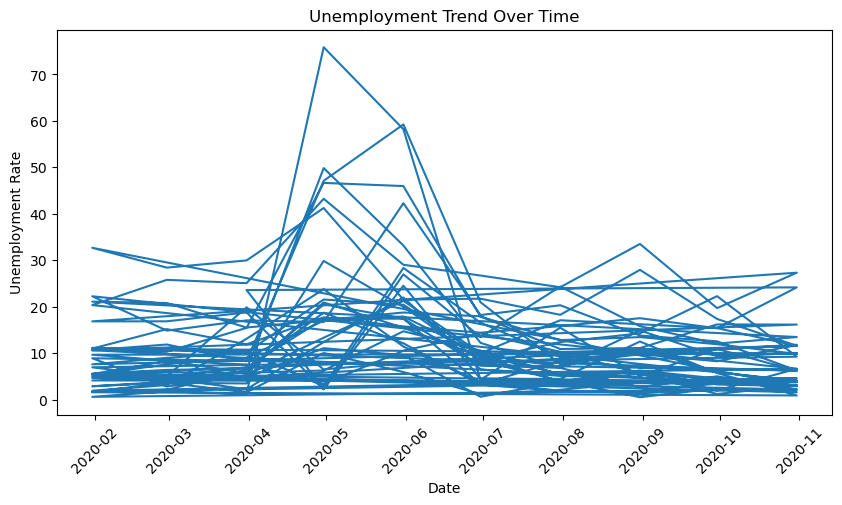

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data2[' Date'], data2[' Estimated Unemployment Rate (%)'])
plt.title("Unemployment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)
plt.show()

## Visualization 2 — State Analysis

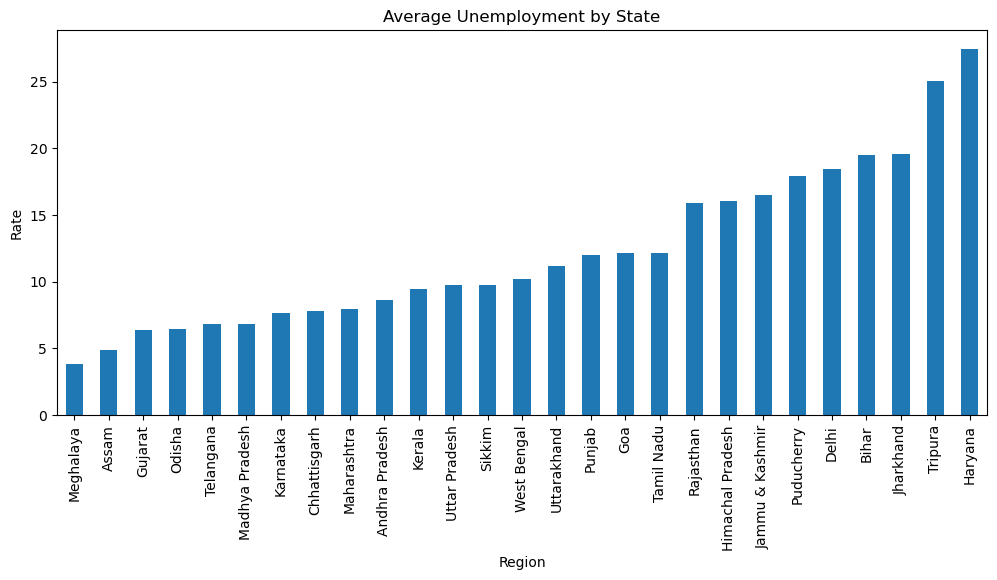

In [10]:
state_avg = data2.groupby('Region')[' Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,5))
state_avg.sort_values().plot(kind='bar')
plt.title("Average Unemployment by State")
plt.ylabel("Rate")
plt.show()

## Visualization 3 — Distribution

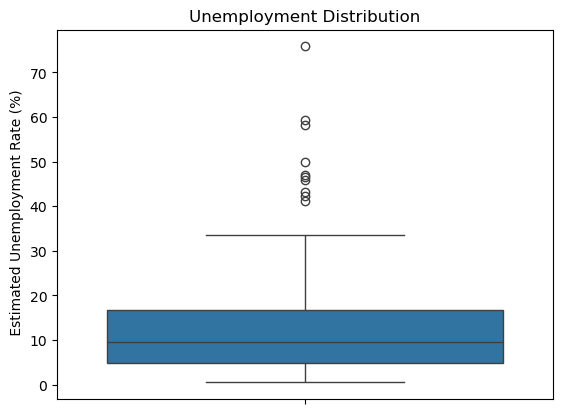

In [11]:
plt.figure()
sns.boxplot(y=data2[' Estimated Unemployment Rate (%)'])
plt.title("Unemployment Distribution")
plt.show()

## Visualization 4 — Heatmap (Month vs Year)

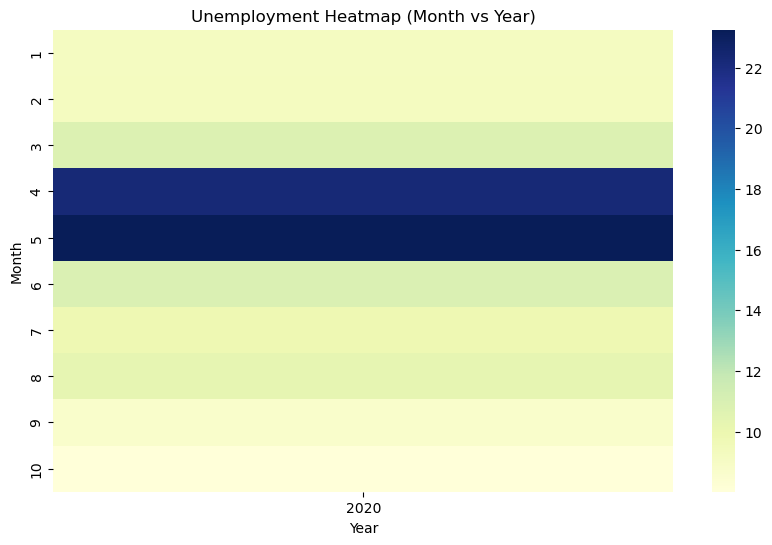

In [12]:
pivot = data2.pivot_table(
    values=' Estimated Unemployment Rate (%)',
    index='Month',
    columns='Year'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Unemployment Heatmap (Month vs Year)")
plt.show()

## Covid Impact Analysis

In [13]:
before_covid = data2[data2[' Date'] < '2020-03-01'][' Estimated Unemployment Rate (%)'].mean()
after_covid = data2[data2[' Date'] >= '2020-03-01'][' Estimated Unemployment Rate (%)'].mean()

print("Before Covid:", before_covid)
print("After Covid:", after_covid)

Before Covid: 9.231346153846154
After Covid: 12.963860465116278


## Visualization — Covid Comparison

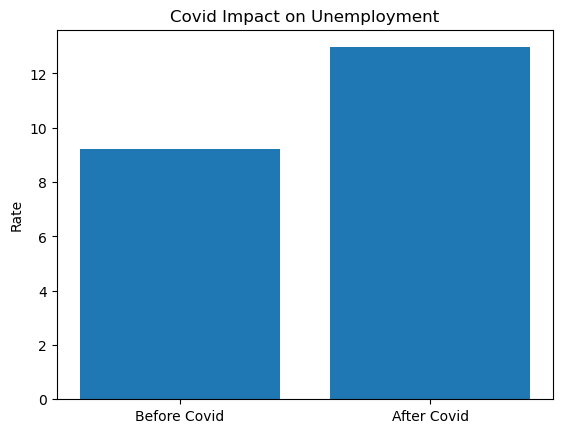

In [14]:
plt.figure()
plt.bar(['Before Covid', 'After Covid'], [before_covid, after_covid])
plt.title("Covid Impact on Unemployment")
plt.ylabel("Rate")
plt.show()

## 🧠 Insights:

- Unemployment rate increased significantly after the Covid-19 period.
- There are clear differences between states in unemployment levels.
- Some states are more affected economically than others.
- Seasonal variations are visible in the dataset.
- Data can be used for future forecasting models.